Test accuracy with adversarial attack for different epsilon

In [1]:

import torch
from flip.models import load_model
from flip.attacks import pgd
from flip.train import StandardTrainer, FLIPTrainer, AdversarialTrainer, TVTrainer
from flip.load_data import load_MNIST_test, load_MNIST, split_loader
from flip.utils.config import cfg, dataset, model_attributes
from flip.test import attack_model, eval_acc
import numpy as np
import matplotlib.pyplot as plt
import time 


In [2]:

# In this cell you can find the parameter that would be interesting to change
lenght = 20 # lenght of epsilon list
epsilon_test_list = np.logspace(-3, -0.2, lenght)
adversarial_test = "pgd" # "fgsm"

dataset_name = 'MNIST'
epochs = 5 # for each model : how many time is it trained

n_model = 3 # how many model are trained for every type of training



In [3]:


time_v = [time.time()]
for i in range(n_model-1):
    time_v.append(time_v[-1]+2)

CFG = cfg(data=dataset(name=dataset_name, download = False), 
          model = model_attributes(
              name = 'FC', 
              sizes=[784, 200, 80, 10],
              act_fun = 'ReLU',
              file_name = 'model_compare_adv_v' + str(round(time_v[0])) + '.pth',
              )
          )


In [4]:
# split data
dataloader, validation_loader, test_loader = split_loader(CFG, train_split=0.8)

[1722503452.0102744, 1722503454.0102744, 1722503456.0102744]
Training model :model_compare_adv_v1722503452.pth
init adv acc for adversarial:  tensor(0.)
Begin Adversarial Training for model number  0
--------------------------------------------------
Epoch: 0
acc: tensor(0.6500)
loss: 0.014350217670202255
--------------------------------------------------
Epoch: 1
acc: tensor(0.7870)
loss: 0.013137587425609429
val_acc: 0.00016666666666666666
--------------------------------------------------
Epoch: 2
acc: tensor(0.8517)
loss: 0.012634114151199659
val_acc: 0.0010833333333333333
--------------------------------------------------
Epoch: 3
acc: tensor(0.8792)
loss: 0.01240857017536958
val_acc: 0.0004166666666666667
--------------------------------------------------
Epoch: 4
acc: tensor(0.8957)
loss: 0.012270875622828801
val_acc: 0.0011666666666666668
Training model :model_compare_adv_v1722503454.pth
init adv acc for adversarial:  tensor(0.)
Begin Adversarial Training for model number  1
--

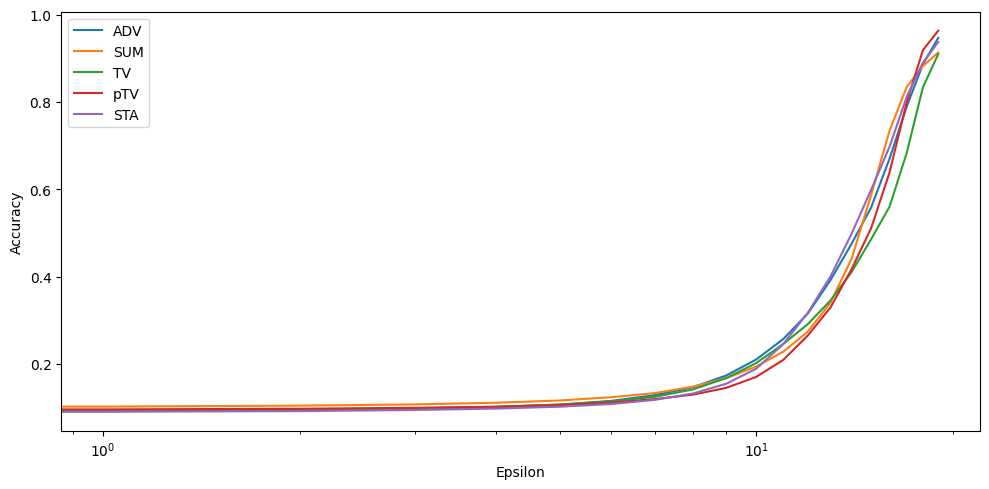

In [5]:


acc_ADV =[0]*lenght
acc_TV = [0]*lenght
acc_SUM = [0]*lenght
acc_STA = [0]*lenght
acc_pTV = [0]*lenght
elapsed_time_ADV = 0
elapsed_time_TV = 0
elapsed_time_SUM = 0
elapsed_time_STA = 0
elapsed_time_pTV = 0

print(time_v)

for i in range(n_model):
    CFG.model.file_name = 'model_compare_adv_v' + str(round(time_v[i])) + '.pth'
    print('Training model :' + CFG.model.file_name)
    model_ADV = load_model.load(CFG)
    trainer = AdversarialTrainer(model_ADV, dataloader, val_loader=validation_loader,
                            opt_kwargs={'type': torch.optim.Adam },
                            adv_kwargs = {'type' : "fgsm", 'epsilon' : 0.05},
                            verbosity=1,
                            epochs=epochs,)
    print('init adv acc for adversarial: ', attack_model(model_ADV, dataloader, attack_kwargs = {'type':"fgsm", 'epsilon':1., 'max_iters':1})) # Expected to be near 0
    print('Begin Adversarial Training for model number ', i)
    start_time = time.time()
    trainer.train()
    elapsed_time_ADV += (time.time() - start_time)/n_model

for e in range(lenght):
    for i in range(n_model):
        CFG.model.file_name = 'model_compare_adv_v' + str(round(time_v[i])) + '.pth'
        model_ADV = load_model.load(CFG)
        acc_ADV[e] += attack_model(model_ADV, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_ADV[e] /= n_model

for i in range(n_model):
    CFG.model.file_name = 'model_compare_TV_v' + str(round(time_v[i])) + '.pth'
    model_TV = load_model.load(CFG)
    trainer = TVTrainer(model_TV, dataloader, val_loader=validation_loader,
                        lamda=0.7,
                        num_iters=2,
                        approximation_decrep=0.3,
                        opt_kwargs={'type': torch.optim.Adam },
                        upd_kwargs={'name' : 'SGD', 'lr' : 0.07},
                        verbosity=1,
                        epochs=epochs,
                        min_acc=1.,)
    print('init adv acc for TV: ', attack_model(model_TV, dataloader, attack_kwargs = {'type':"fgsm", 'epsilon':1., 'max_iters':1})) # Expected to be near 0
    print('Begin TV Training for model number ', i)
    start_time = time.time()
    trainer.train()
    elapsed_time_TV += (time.time() - start_time)/n_model

for e in range(lenght):
    for i in range(n_model):
        CFG.model.file_name = 'model_compare_TV_v' + str(round(time_v[i])) + '.pth'
        model_TV = load_model.load(CFG)
        acc_TV[e] += attack_model(model_TV, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_TV[e] /= n_model

for i in range(n_model):
    CFG.model.file_name = 'model_compare_SUM_v' + str(round(time_v[i])) + '.pth'
    model_SUM = load_model.load(CFG)
    trainer = FLIPTrainer(model_SUM, dataloader, val_loader=validation_loader,
                        lamda=0.7,
                        num_iters=2,
                        estimation='sum',
                        opt_kwargs={'type': torch.optim.Adam },
                        upd_kwargs={'name' : 'SGD', 'lr' : 0.07},
                        verbosity=1,
                        epochs=epochs,
                        min_acc=1.,)
    print('init adv acc for SUM: ', attack_model(model_SUM, dataloader, attack_kwargs = {'type':"fgsm", 'epsilon':1., 'max_iters':1})) # Expected to be near 0
    print('Begin SUM Training for model number ', i)
    start_time = time.time()
    trainer.train()
    elapsed_time_SUM += (time.time() - start_time)/n_model

for e in range(lenght):
    for i in range(n_model):
        CFG.model.file_name = 'model_compare_SUM_v' + str(round(time_v[i])) + '.pth'
        model_SUM = load_model.load(CFG)
        acc_SUM[e] += attack_model(model_SUM, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_SUM[e] /= n_model
    

for i in range(n_model):
    CFG.model.file_name = 'model_compare_STA_v' + str(round(time_v[i])) + '.pth'
    model_STA = load_model.load(CFG)
    trainer = StandardTrainer(model_STA, dataloader, val_loader=validation_loader,
                        opt_kwargs={'type': torch.optim.Adam },
                        verbosity=1,
                        epochs=epochs,)
    print('init adv acc for STA: ', attack_model(model_STA, dataloader, attack_kwargs = {'type':"fgsm", 'epsilon':1., 'max_iters':1})) # Expected to be near 0
    print('Begin STA Training for model number ', i)
    start_time = time.time()
    trainer.train()
    elapsed_time_STA += (time.time() - start_time)/n_model

for e in range(lenght):
    for i in range(n_model):
        CFG.model.file_name = 'model_compare_STA_v' + str(round(time_v[i])) + '.pth'
        model_STA = load_model.load(CFG)
        acc_STA[e] += attack_model(model_STA, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_STA[e] /= n_model

for i in range(n_model):
    CFG.model.file_name = 'model_compare_pTV_v' + str(round(time_v[i])) + '.pth'
    model_pTV = load_model.load(CFG)
    trainer = TVTrainer(model_pTV, dataloader, val_loader=validation_loader,
                        lamda=0.7,
                        num_iters=2,
                        projection=True,
                        approximation_decrep=0.3,
                        opt_kwargs={'type': torch.optim.Adam },
                        upd_kwargs={'name' : 'SGD', 'lr' : 0.07},
                        verbosity=1,
                        epochs=epochs,
                        min_acc=1.,)
    print('init adv acc for pTV: ', attack_model(model_pTV, dataloader, attack_kwargs = {'type':"fgsm", 'epsilon':1., 'max_iters':1})) # Expected to be near 0
    print('Begin pTV Training for model number ', i)
    start_time = time.time()
    trainer.train()
    elapsed_time_pTV += (time.time() - start_time)/n_model

for e in range(lenght):
    for i in range(n_model):
        CFG.model.file_name = 'model_compare_pTV_v' + str(round(time_v[i])) + '.pth'
        model_pTV = load_model.load(CFG)
        acc_pTV[e] += attack_model(model_pTV, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_pTV[e] /= n_model
    

print('time SUM: ', elapsed_time_SUM)
print('time TV: ', elapsed_time_TV)
print('time pTV: ', elapsed_time_pTV)
print('time ADV: ', elapsed_time_ADV)
print('time STA: ', elapsed_time_STA)

plt.figure(figsize=(10, 5))

# Plot acc
plt.plot(acc_ADV, label='ADV')
plt.plot(acc_SUM, label='SUM')
plt.plot(acc_TV, label='TV')
plt.plot(acc_pTV, label='pTV')
plt.plot(acc_STA, label='STA')
plt.xlabel('Epsilon')
plt.xscale('log')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


------ Computation of the accuracy for each model ------
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test


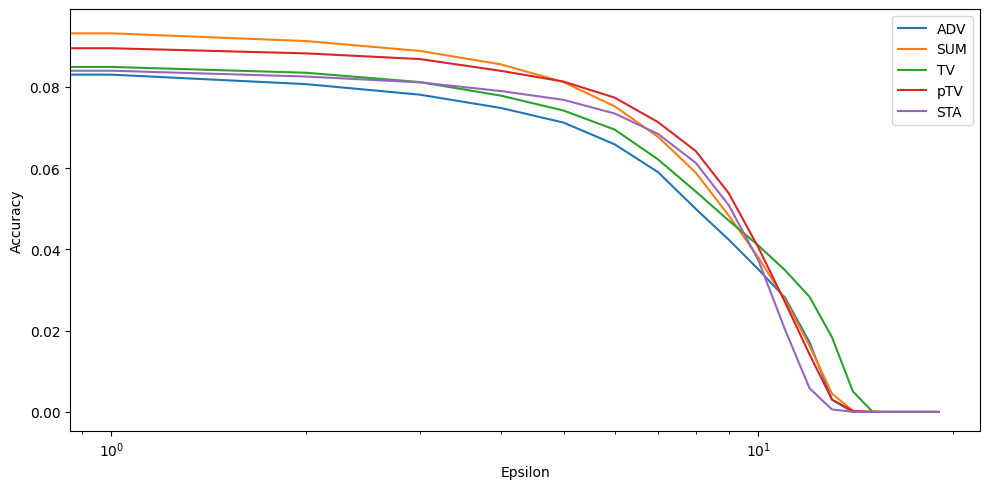

In [6]:
acc_ADV =[0]*lenght
acc_TV = [0]*lenght
acc_SUM = [0]*lenght
acc_STA = [0]*lenght
acc_pTV = [0]*lenght

adversarial_test = "fgsm"
print("------ Computation of the accuracy for each model ------")

for e in range(lenght):
    for i in range(n_model):
        print("test")
        CFG.model.file_name = 'model_compare_adv_v' + str(round(time_v[i])) + '.pth'
        model_ADV = load_model.load(CFG)
        acc_ADV[e] += attack_model(model_ADV, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_ADV[e] /= n_model


for e in range(lenght):
    for i in range(n_model):
        CFG.model.file_name = 'model_compare_TV_v' + str(round(time_v[i])) + '.pth'
        model_TV = load_model.load(CFG)
        acc_TV[e] += attack_model(model_TV, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_TV[e] /= n_model


for e in range(lenght):
    for i in range(n_model):
        CFG.model.file_name = 'model_compare_SUM_v' + str(round(time_v[i])) + '.pth'
        model_SUM = load_model.load(CFG)
        acc_SUM[e] += attack_model(model_SUM, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_SUM[e] /= n_model
    

for e in range(lenght):
    for i in range(n_model):
        CFG.model.file_name = 'model_compare_STA_v' + str(round(time_v[i])) + '.pth'
        model_STA = load_model.load(CFG)
        acc_STA[e] += attack_model(model_STA, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_STA[e] /= n_model


for e in range(lenght):
    for i in range(n_model):
        CFG.model.file_name = 'model_compare_pTV_v' + str(round(time_v[i])) + '.pth'
        model_pTV = load_model.load(CFG)
        acc_pTV[e] += attack_model(model_pTV, test_loader, attack_kwargs = {'type': adversarial_test, 'epsilon': epsilon_test_list[e]})
    acc_pTV[e] /= n_model
    

print("test")
plt.figure(figsize=(10, 5))

# Plot acc
plt.plot(acc_ADV, label='ADV')
plt.plot(acc_SUM, label='SUM')
plt.plot(acc_TV, label='TV')
plt.plot(acc_pTV, label='pTV')
plt.plot(acc_STA, label='STA')
plt.xlabel('Epsilon')
plt.xscale('log')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()